# 1. Import Libraries

In [51]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import eda_functions

In [52]:
import importlib
importlib.reload(eda_functions)

<module 'eda_functions' from 'D:\\NEW_WORK_MAY 26\\flight_price_prediction_sagemaker\\notebooks\\eda_functions.py'>

# 2. Read the train data

In [53]:
file_path = r"D:\NEW_WORK_MAY 26\flight_price_prediction_sagemaker\data\train.csv"
train = pd.read_csv(file_path)

In [54]:
train.dtypes

airline             object
date_of_journey     object
source              object
destination         object
dep_time            object
arrival_time        object
duration             int64
total_stops        float64
additional_info     object
price                int64
dtype: object

In [55]:
train["date_of_journey"].unique()[:20]

array(['2019-05-03', '2019-03-21', '2019-06-27', '2019-05-09',
       '2019-05-27', '2019-05-24', '2019-06-12', '2019-05-15',
       '2019-06-06', '2019-04-01', '2019-04-24', '2019-05-12',
       '2019-06-09', '2019-05-01', '2019-05-21', '2019-03-03',
       '2019-03-27', '2019-03-01', '2019-06-01', '2019-06-24'],
      dtype=object)

In [56]:
for col in ["date_of_journey", "dep_time", "arrival_time"]:
    try:
        pd.to_datetime(train[col], dayfirst=True)
        print(f"{col}: OK")
    except Exception as e:
        print(f"{col}:")
        print(e)
        print("-" * 50)

date_of_journey:
unconverted data remains when parsing with format "%Y-%d-%m": "1", at position 1. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.
--------------------------------------------------
dep_time: OK
arrival_time: OK


In [57]:
train = train.assign(**{
	col: pd.to_datetime(train.loc[:, col], dayfirst=True, format="mixed")
	for col in ["date_of_journey", "dep_time", "arrival_time"]
})

train.dtypes

airline                    object
date_of_journey    datetime64[ns]
source                     object
destination                object
dep_time           datetime64[ns]
arrival_time       datetime64[ns]
duration                    int64
total_stops               float64
additional_info            object
price                       int64
dtype: object

# 3. High level Summary of data

In [58]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   airline          640 non-null    object        
 1   date_of_journey  640 non-null    datetime64[ns]
 2   source           640 non-null    object        
 3   destination      640 non-null    object        
 4   dep_time         640 non-null    datetime64[ns]
 5   arrival_time     640 non-null    datetime64[ns]
 6   duration         640 non-null    int64         
 7   total_stops      640 non-null    float64       
 8   additional_info  640 non-null    object        
 9   price            640 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(4)
memory usage: 50.1+ KB


In [59]:
train.describe(include="number")

,duration,total_stops,price
count,640.000000,640.000000,640.000000
mean,634.382812,0.784375,9108.579687
std,513.972883,0.664602,4917.348024
min,75.000000,0.000000,1965.000000
25%,170.000000,0.000000,5566.000000
50%,477.500000,1.000000,8086.000000
75%,925.000000,1.000000,12414.500000
max,2820.000000,3.000000,54826.000000


In [60]:
train.head()

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price
0,Jet Airways,2019-05-03,Mumbai,Hyderabad,2026-07-23 10:20:00,2026-07-23 11:50:00,90,0.0,In-flight meal not included,4995
1,Jet Airways,2019-03-21,Banglore,New Delhi,2026-07-23 22:50:00,2026-07-23 10:25:00,695,1.0,In-flight meal not included,7832
2,Multiple Carriers,2019-06-27,Delhi,Cochin,2026-07-23 08:45:00,2026-07-23 21:00:00,735,1.0,No Info,7005
3,Air India,2019-05-09,Banglore,Delhi,2026-07-23 17:00:00,2026-07-23 19:45:00,165,0.0,No Info,5228
4,Jet Airways,2019-05-27,Banglore,Delhi,2026-07-23 19:50:00,2026-07-23 22:50:00,180,0.0,No Info,7229


In [61]:
(
    train
    .assign(total_stops=train["total_stops"].astype(object))
    .describe(include="O")
)

,airline,source,destination,total_stops,additional_info
count,640,640,640,640.0,640
unique,8,5,6,4.0,4
top,Jet Airways,Delhi,Cochin,1.0,No Info
freq,258,255,255,334.0,494


# 4. High level analysis of missing values in the data

In [62]:
train.isnull().sum()

airline            0
date_of_journey    0
source             0
destination        0
dep_time           0
arrival_time       0
duration           0
total_stops        0
additional_info    0
price              0
dtype: int64

In [63]:
def missing_info(data):
  na_cols = [col for col in data.columns if data[col].isna().any()]
  na_counts = [data[col].isna().sum() for col in na_cols]
  na_pct = [(data[col].isna().mean() * 100) for col in na_cols]

  return (
      pd
      .DataFrame(data={
          "variable": na_cols,
          "count": na_counts,
          "percentage": na_pct
      })
      .sort_values(by="count", ascending=False)
      .set_index("variable")
  )

In [64]:
eda_functions.missing_info(train)

,count,percentage
variable,,


# 5. High level analysis of outliers

In [65]:
from sklearn.ensemble import IsolationForest

In [66]:
forest = IsolationForest(n_estimators=10, random_state=42)

In [67]:
(
    train
    .assign(outlier=forest.fit_predict(train
                                       .drop(columns="price")
                                       .select_dtypes(include="number"))
           )
    .query("outlier == -1")
)

,airline,date_of_journey,source,destination,dep_time,arrival_time,duration,total_stops,additional_info,price,outlier
6,Indigo,2019-06-12,Delhi,Cochin,2026-07-23 14:25:00,2026-07-23 17:40:00,195,0.0,No Info,5601,-1
10,Indigo,2019-04-01,Mumbai,Hyderabad,2026-07-23 20:05:00,2026-07-23 21:40:00,95,0.0,No Info,2227,-1
12,Air India,2019-05-12,Kolkata,Banglore,2026-07-23 10:00:00,2026-07-23 05:25:00,1165,2.0,No Info,14634,-1
18,Jet Airways,2019-05-21,Kolkata,Banglore,2026-07-23 09:35:00,2026-07-23 14:25:00,1730,1.0,No Info,11467,-1
21,Vistara,2019-03-27,Delhi,Cochin,2026-07-23 06:00:00,2026-07-23 09:10:00,190,0.0,No Info,4851,-1
...,...,...,...,...,...,...,...,...,...,...,...
609,Jet Airways,2019-06-09,Kolkata,Banglore,2026-07-23 21:10:00,2026-07-23 23:35:00,1585,1.0,In-flight meal not included,10844,-1
612,Spicejet,2019-06-18,Chennai,Kolkata,2026-07-23 08:20:00,2026-07-23 10:35:00,135,0.0,No check-in baggage included,3543,-1
619,Indigo,2019-04-24,Delhi,Cochin,2026-07-23 20:25:00,2026-07-23 01:30:00,305,1.0,No Info,5065,-1
631,Goair,2019-06-01,Delhi,Cochin,2026-07-23 07:25:00,2026-07-23 13:35:00,370,1.0,No Info,6393,-1


In [68]:
(
    train
    .assign(outlier=forest.fit_predict(train
                                       .drop(columns="price")
                                       .select_dtypes(include="number"))
           )
    .query("outlier == -1")
    .duration
    .describe()
)

count     236.000000
mean      926.652542
std       635.657828
min        75.000000
25%       305.000000
50%      1035.000000
75%      1516.250000
max      2820.000000
Name: duration, dtype: float64

In [69]:
train.select_dtypes(include="number")

,duration,total_stops,price
0,90,0.0,4995
1,695,1.0,7832
2,735,1.0,7005
3,165,0.0,5228
4,180,0.0,7229
...,...,...,...
635,165,0.0,3943
636,910,1.0,6795
637,765,1.0,7480
638,155,0.0,4804


# 6. Pair plots

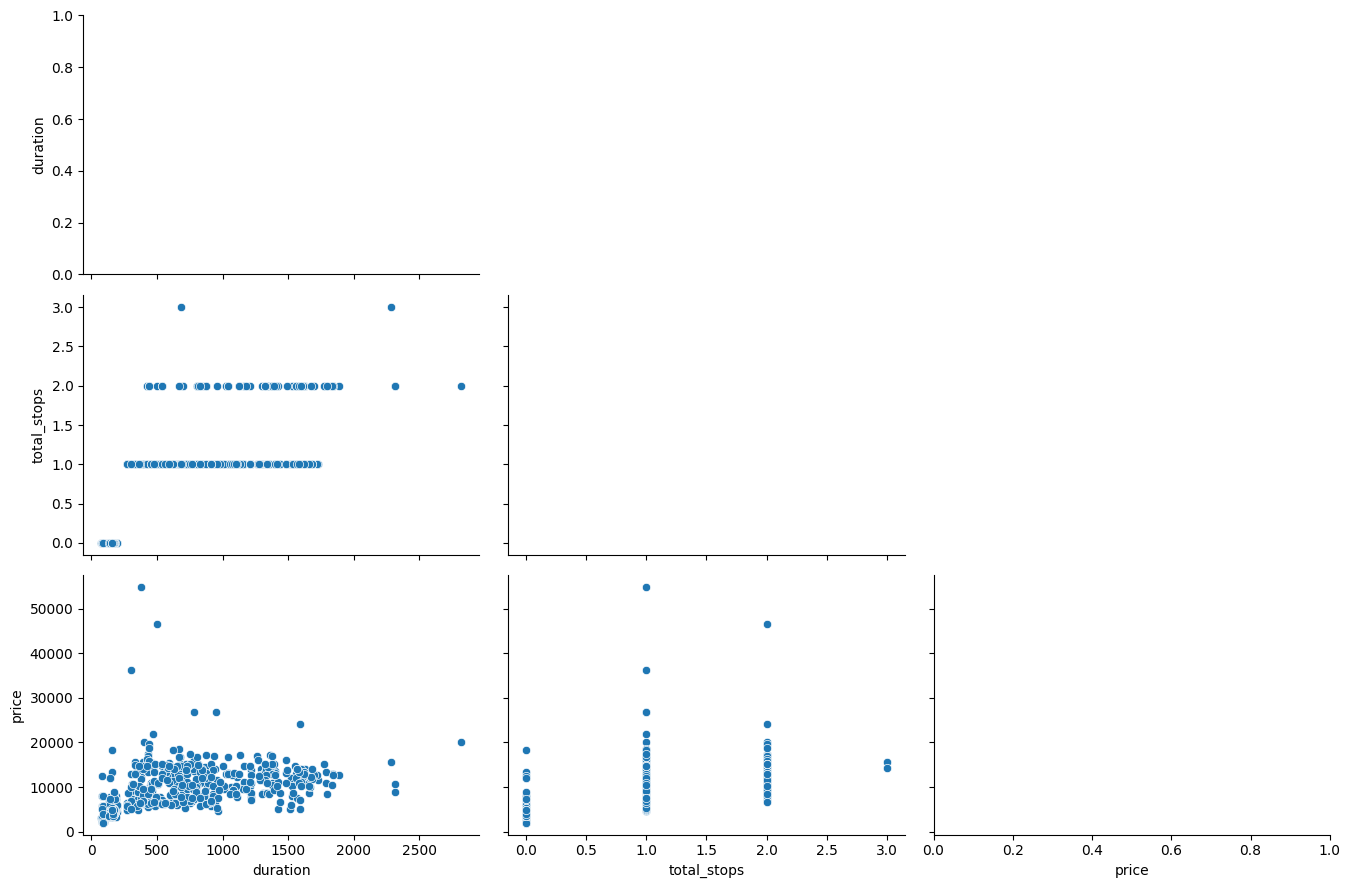

In [70]:
eda_functions.pair_plots(train,
               height = 3,
               aspect = 1.5,
               hue = None,
               legend = False)

# Correlation Plots

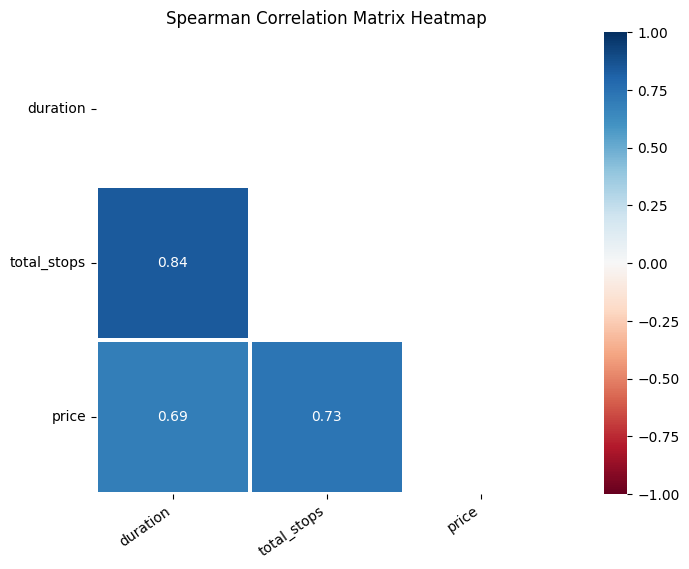

In [71]:
eda_functions.correlation_heatmap(train,
                        figsize = (12,6),
                        method = "spearman",
                        cmap = "RdBu")

In [72]:
train.corr(method="spearman", numeric_only=True)

,duration,total_stops,price
duration,1.000000,0.837371,0.689058
total_stops,0.837371,1.000000,0.728032
price,0.689058,0.728032,1.000000


# 8. Detailed analysis

In [73]:
train.columns

Index(['airline', 'date_of_journey', 'source', 'destination', 'dep_time',
       'arrival_time', 'duration', 'total_stops', 'additional_info', 'price'],
      dtype='object')

In [74]:
train.airline.describe()

count             640
unique              8
top       Jet Airways
freq              258
Name: airline, dtype: object

In [75]:
eda_functions.cat_summary(train, 'airline')

0            Jet Airways
1            Jet Airways
2      Multiple Carriers
3              Air India
4            Jet Airways
             ...        
635               Indigo
636    Multiple Carriers
637            Air India
638               Indigo
639          Jet Airways
Name: airline, Length: 640, dtype: object

Data Type      : object
Cardinality    : 8 categories
Missing Data   : 0 rows (0.00 %)
Available Data : 640 / 640 rows


,
count,640
unique,8
top,Jet Airways
freq,258


,count,percentage
category,,
Jet Airways,258,0.403125
Indigo,117,0.182812
Air India,87,0.135937
Multiple Carriers,75,0.117188
Spicejet,53,0.082812
Vistara,28,0.043750
Air Asia,14,0.021875
Goair,8,0.012500


In [76]:
def cat_univar_plots(data,
                     var,
                     k=None,
                     order=None,
                     show_wordcloud=True,
                     figsize=(12, 8.5)):
  display_html(2, f"Univariate Analysis of {var}")
  display_html(content="")

  fig = plt.figure(figsize=figsize)
  gs = GridSpec(2, 2, figure=fig)
  ax1 = fig.add_subplot(gs[0, 0]) # bar-chart
  ax2 = fig.add_subplot(gs[0, 1]) # pie-chart
  ax3 = fig.add_subplot(gs[1, :]) # word-cloud

  if k is None:
    counts = (
        data
        .loc[:, var]
        .value_counts()
        .reindex(index=order)
    )
  else:
    temp = get_top_k(
        data,
        var,
        k=k
    )
    counts = (
        temp
        .loc[:, var]
        .value_counts()
    )

  colors = [tuple(np.random.choice(256, size=3) / 255) for _ in range(len(counts))]

  # bar-chart
  bar_chart(
      counts,
      colors,
      ax1
  )

  # pie_chart
  pie_chart(
      counts,
      colors,
      ax2
  )

  # word-cloud
  if show_wordcloud:
    var_string = " ".join(
        data
        .loc[:, var]
        .dropna()
        .str.replace(" ", "_")
        .to_list()
    )

    word_cloud = WordCloud(
        width=2000,
        height=700,
        random_state=42,
        background_color="black",
        colormap="Set2",
        stopwords=STOPWORDS
    ).generate(var_string)

    ax3.imshow(word_cloud)
    ax3.axis("off")
    ax3.set_title("Word Cloud")
  else:
    ax3.remove()

  plt.tight_layout()
  plt.show()

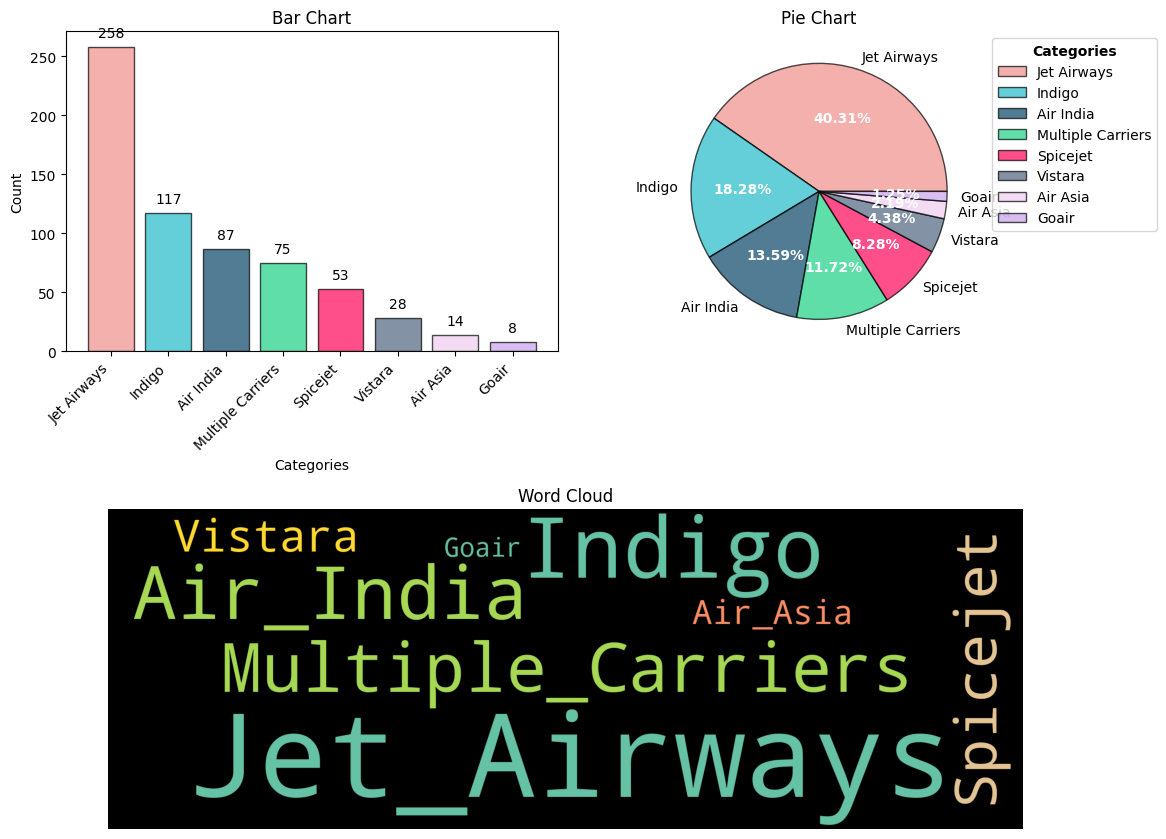

In [77]:
eda_functions.cat_univar_plots(train, 'airline')

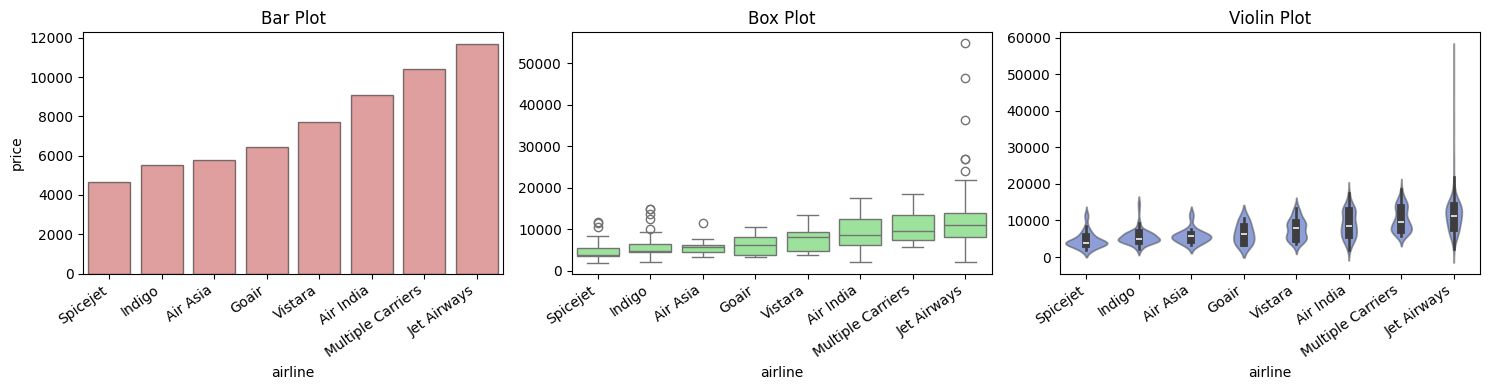

In [78]:
eda_functions.num_cat_bivar_plots(
    	data=train,
	num_var="price",
	cat_var="airline"
)

In [79]:
eda_functions.num_cat_hyp_testing(train, 'price', 'airline')

- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population mean
- Alternate Hypothesis : The groups don't have similar population mean
- Test Statistic       : 39.07471696385295
- p-value              : 1.2250542793106914e-45
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


- Significance Level   : 5.0%
- Null Hypothesis      : The groups have similar population median
- Alternate Hypothesis : The groups don't have similar population median
- Test Statistic       : 271.5208026292605
- p-value              : 7.217307299512683e-55
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and airline are associated to each other


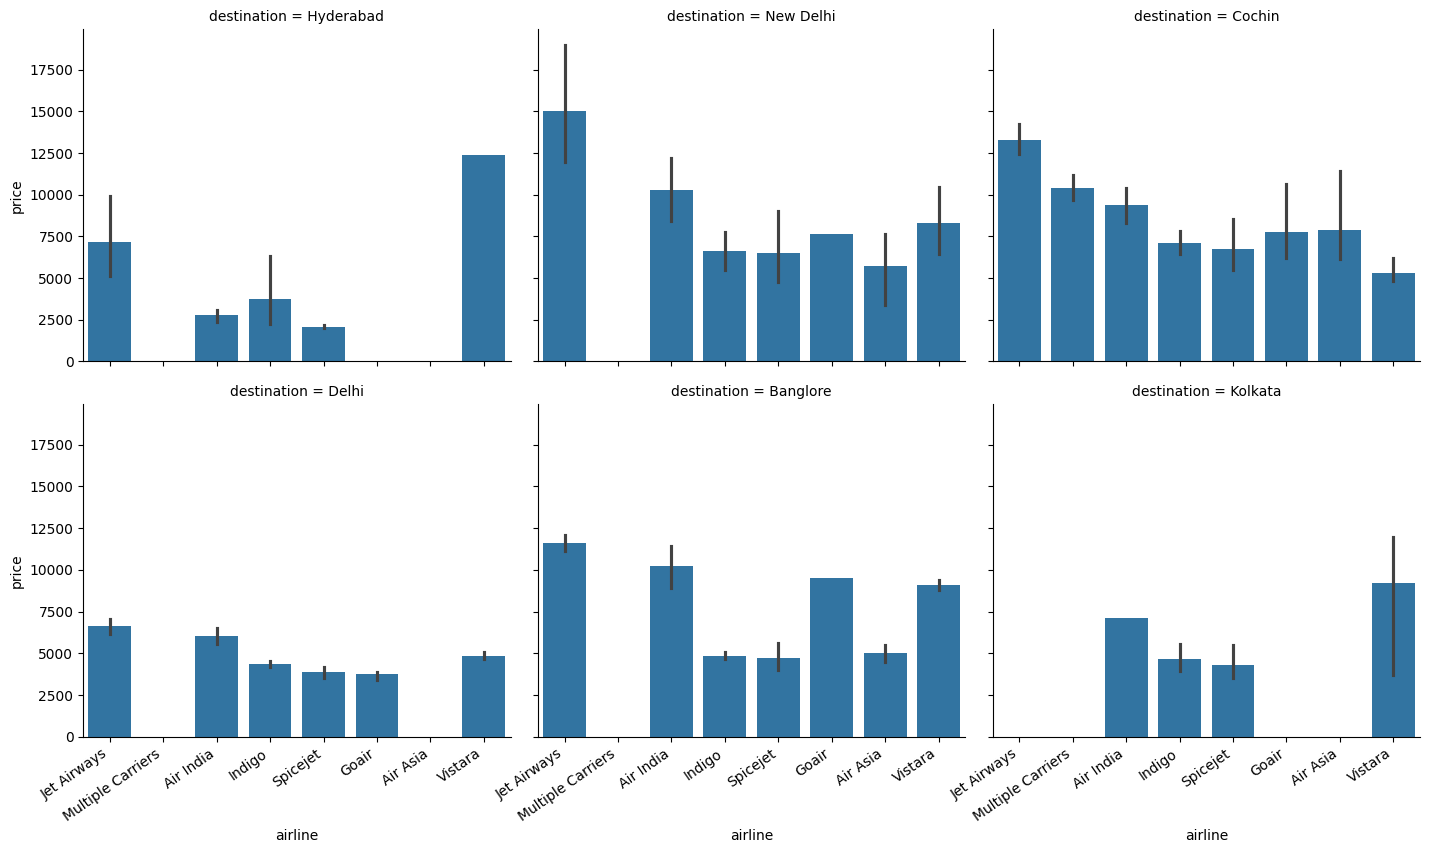

In [80]:
airline_grid = sns.FacetGrid(
    data = train,
    col = 'destination',
    col_wrap = 3,
    height = 4,
    aspect = 1.2,
    sharey = True
)
airline_grid.map(sns.barplot, 'airline', 'price', order=train.airline.unique())
for ax in airline_grid.axes[3:]:
    eda_functions.rotate_xlabels(ax)

### 8.2 date_of_journey

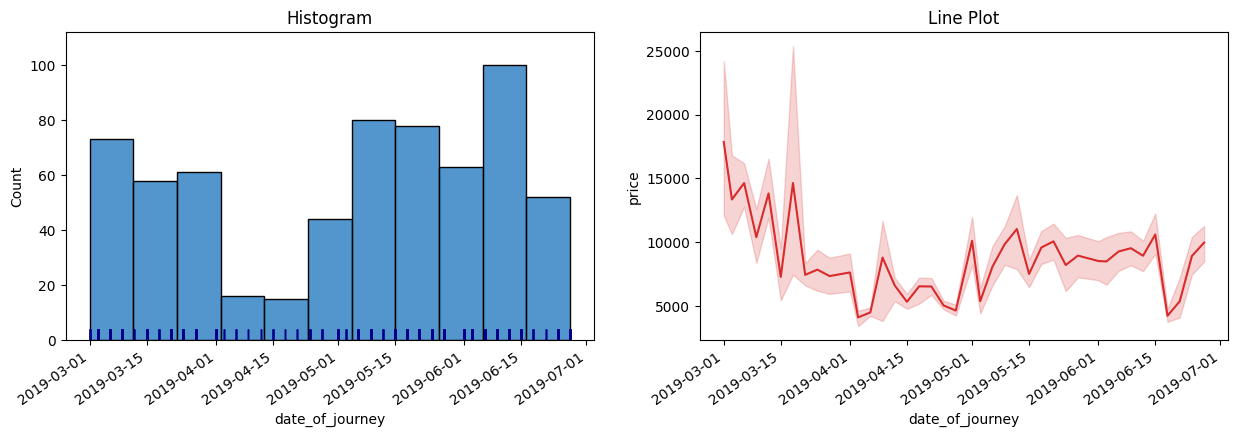

In [81]:
eda_functions.dt_univar_plots(
	data=train,
	var="date_of_journey",
	target="price"
)

In [82]:
train["date_of_journey"].dt.month.value_counts().sort_index()

date_of_journey
3    170
4     73
5    207
6    190
Name: count, dtype: int64

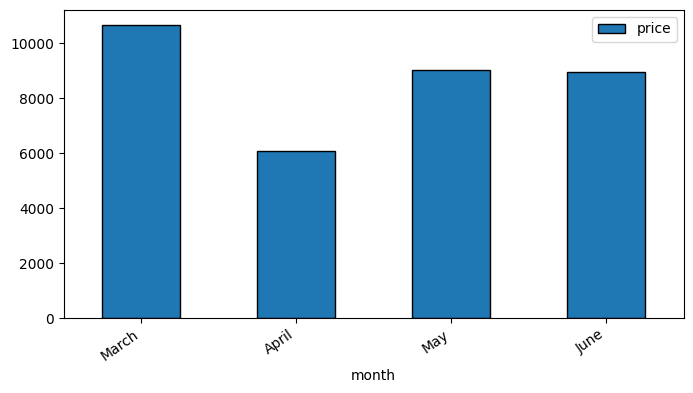

In [83]:
(
	train
	.groupby(pd.Grouper(key="date_of_journey", freq="M"))
	.price.mean()
	.to_frame()
	.set_axis(["March", "April", "May", "June"], axis=0)
	.rename_axis(index="month")
	.plot(
		kind="bar",
		figsize=(8, 4),
		edgecolor="black"
	)
)

ax = plt.gca()
eda_functions.rotate_xlabels(ax)

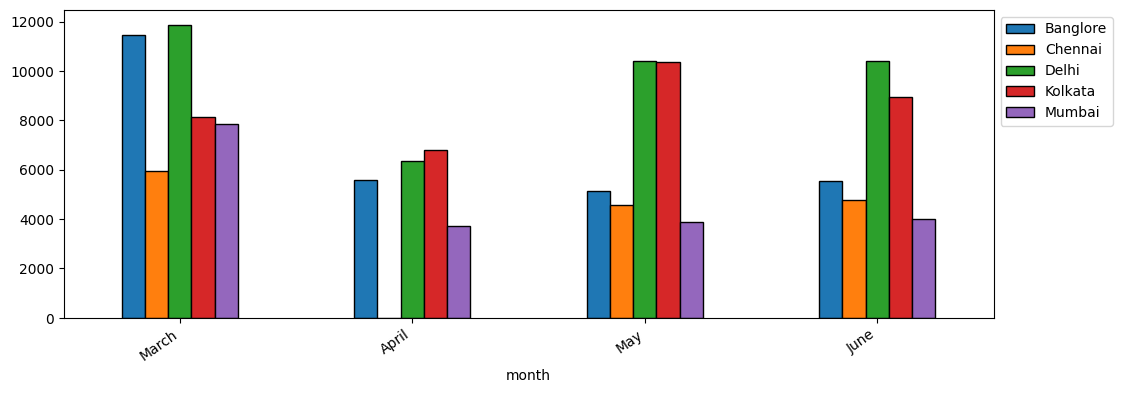

In [84]:

(
	train
	.groupby([pd.Grouper(key="date_of_journey", freq="M"), "source"])
	.price.mean()
	.unstack(fill_value=0)
	.set_axis(["March", "April", "May", "June"], axis=0)
	.rename_axis(index="month")
	.plot(
		kind="bar",
		figsize=(12, 4),
		edgecolor="black"
	)
)

ax = plt.gca()

ax.legend(
	loc="upper left",
	bbox_to_anchor=(1, 1)
)

eda_functions.rotate_xlabels(ax)

### 8.3 dep_time

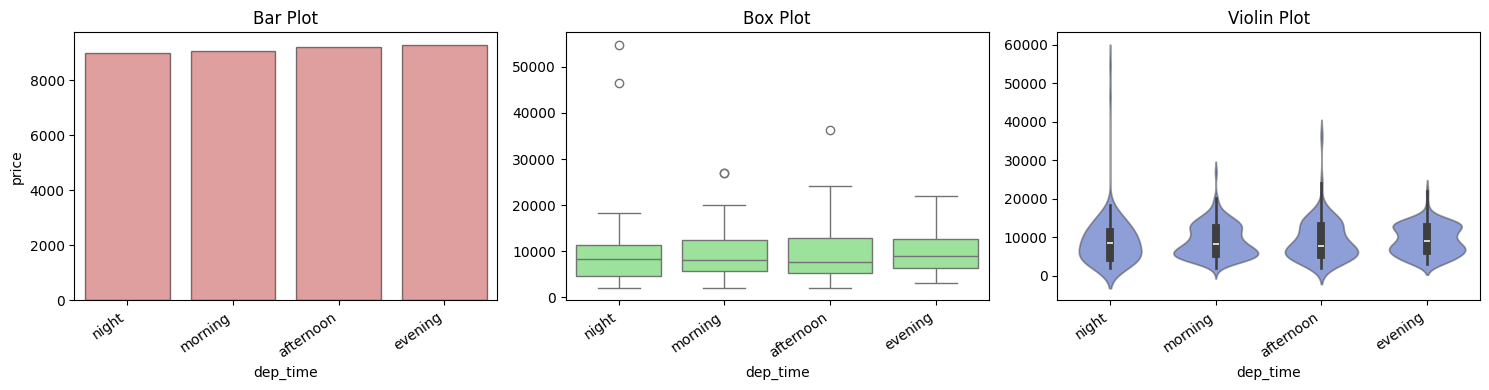

In [85]:
(
	train
	.assign(dep_time=lambda df_: (
		np.select([df_.dep_time.dt.hour.between(4, 12, inclusive="left"),
				   df_.dep_time.dt.hour.between(12, 16, inclusive="left"),
				   df_.dep_time.dt.hour.between(16, 20, inclusive="left")],
				  ["morning", "afternoon", "evening"],
				  default="night")
	))
	.pipe(eda_functions.num_cat_bivar_plots, "price", "dep_time")
)

### 8.4 duration

In [86]:
train.duration

0       90
1      695
2      735
3      165
4      180
      ... 
635    165
636    910
637    765
638    155
639    360
Name: duration, Length: 640, dtype: int64

In [87]:
(
    train
    .dep_time
    .dt.hour
    .pipe(
        lambda ser: pd.Series(
            np.select(
                [
                    ser.between(4, 12, inclusive="left"),
                    ser.between(12, 16, inclusive="left"),
                    ser.between(16, 20, inclusive="left")
                ],
                [
                    "morning",
                    "afternoon",
                    "evening"
                ],
                default="night"
            )
        )
    )
)

0        morning
1          night
2        morning
3        evening
4        evening
         ...    
635      morning
636      morning
637        night
638      evening
639    afternoon
Length: 640, dtype: object

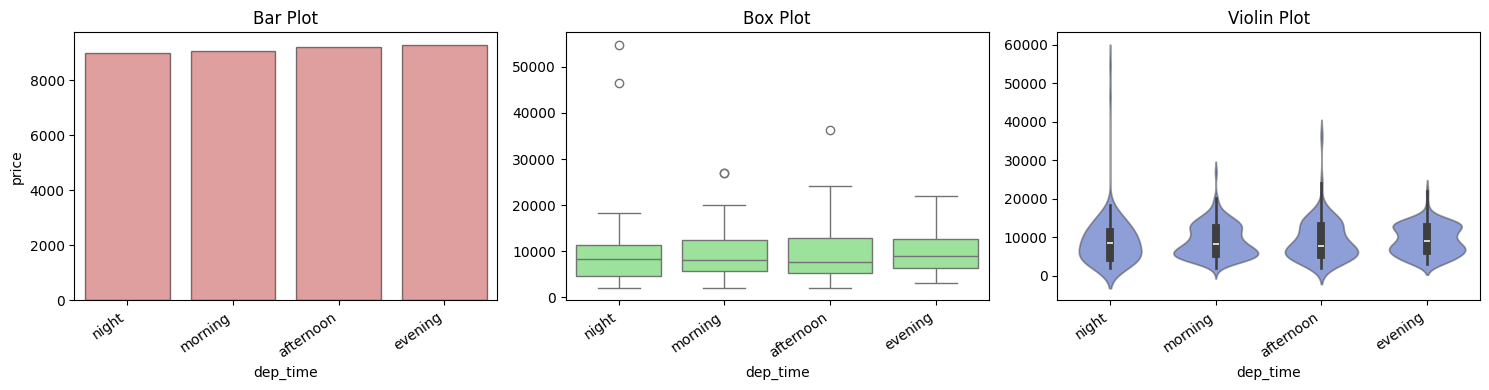

In [88]:
(
	train
	.assign(dep_time=lambda df_: (
		np.select([df_.dep_time.dt.hour.between(4, 12, inclusive="left"),
				   df_.dep_time.dt.hour.between(12, 16, inclusive="left"),
				   df_.dep_time.dt.hour.between(16, 20, inclusive="left")],
				  ["morning", "afternoon", "evening"],
				  default="night")
	))
	.pipe(eda_functions.num_cat_bivar_plots, "price", "dep_time")
)

### 8.4 duration

In [89]:
eda_functions.num_summary(train, "duration")

0       90
1      695
2      735
3      165
4      180
      ... 
635    165
636    910
637    765
638    155
639    360
Name: duration, Length: 640, dtype: int64

Data Type      : int64
Missing Data   : 0 rows (0.00 %)
Available Data : 640 / 640 rows


,value
percentile,
0,75.00
5,90.00
10,140.00
25,170.00
50,477.50
75,925.00
90,1480.50
95,1615.25
99,1836.10


,value
mean,634.382812
trimmed mean (5%),600.034722
trimmed mean (10%),569.423828
median,477.500000


,value
var,264168.123961
std,513.972883
IQR,755.000000
mad,317.500000
coef_variance,0.810194


,value
skewness,0.91965
kurtosis,0.06750


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
p-value              : 6.46370581294648e-22
Test Statistic       : 0.8789469332165775
- Since p-value is less than alpha (0.05), we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


Significance Level   : 0.05
Null Hypothesis      : The data is normally distributed
Alternate Hypothesis : The data is not normally distributed
Critical Value       : 0.782
Test Statistic       : 25.771333461994004
- Since the Test-statistic is greater than Critical Value, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: We conclude that the data sample is not normally distributed


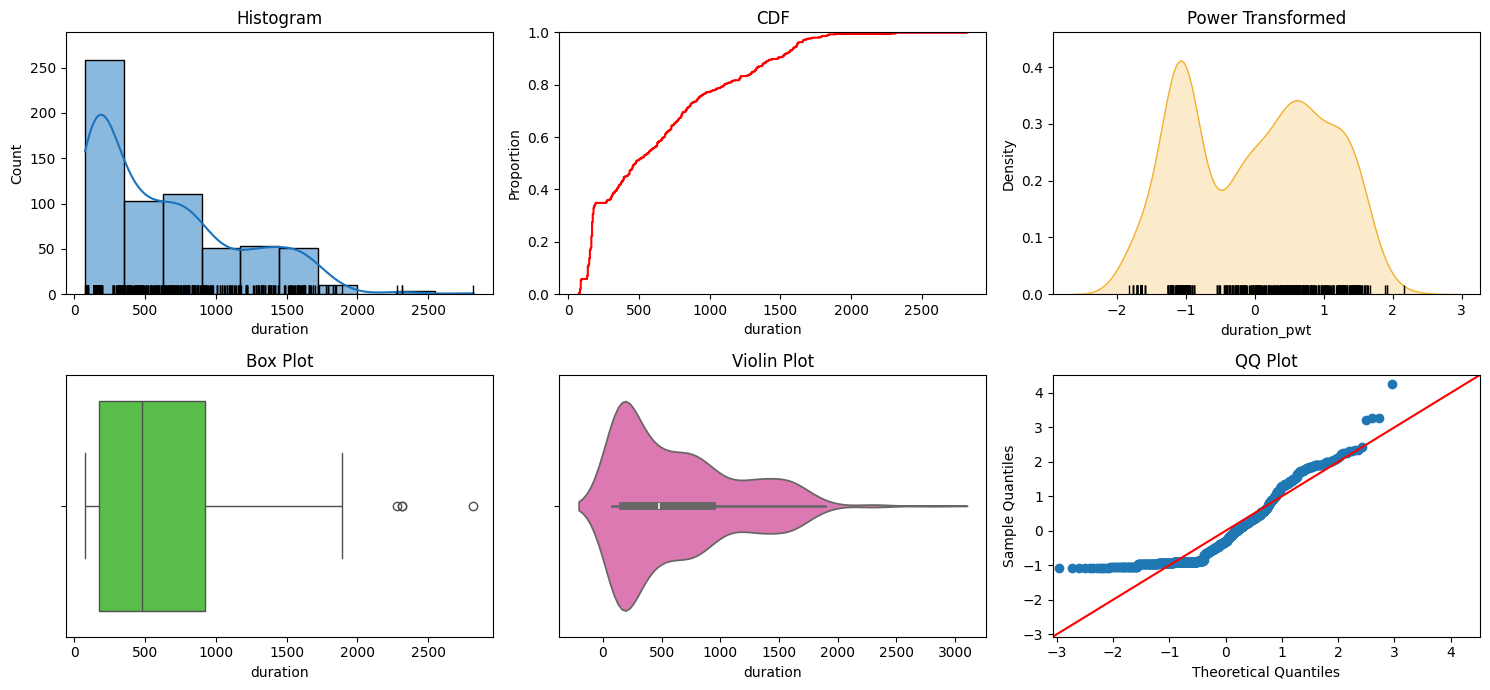

In [90]:
eda_functions.num_univar_plots(train, "duration")

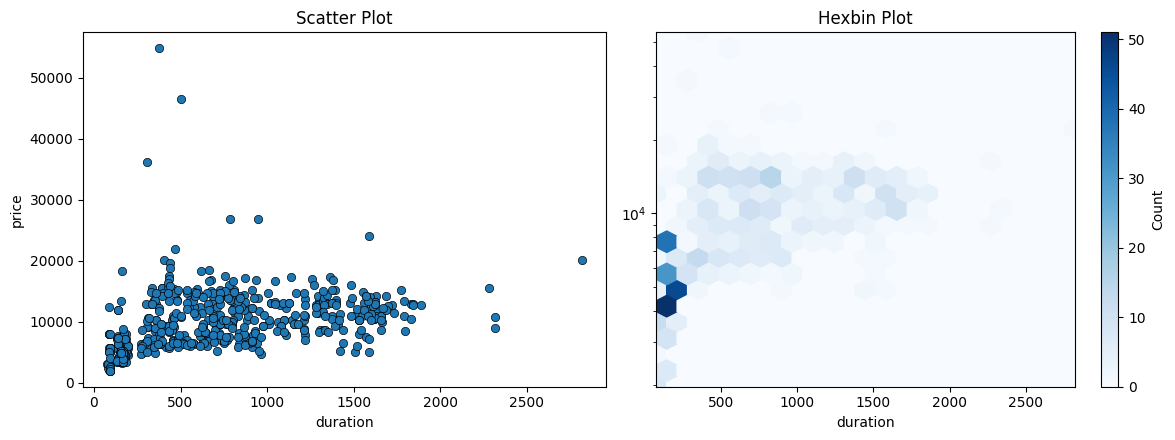

In [91]:
eda_functions.num_bivar_plots(
	train,
	"duration",
	"price",
	hexbin_kwargs=dict(
		yscale="log",
		gridsize=20,
		cmap="Blues"
	)
)

In [92]:
eda_functions.num_num_hyp_testing(train, "price", "duration")

- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.4627262488685744
- p-value              : 2.8248652452511145e-35
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and duration are correlated


- Significance Level   : 5.0%
- Null Hypothesis      : The samples are uncorrelated
- Alternate Hypothesis : The samples are correlated
- Test Statistic       : 0.6890577024171324
- p-value              : 2.7784651364338777e-91
- Since p-value is less than 0.05, we Reject the Null Hypothesis at 5.0% significance level
- CONCLUSION: The variables price and duration are correlated


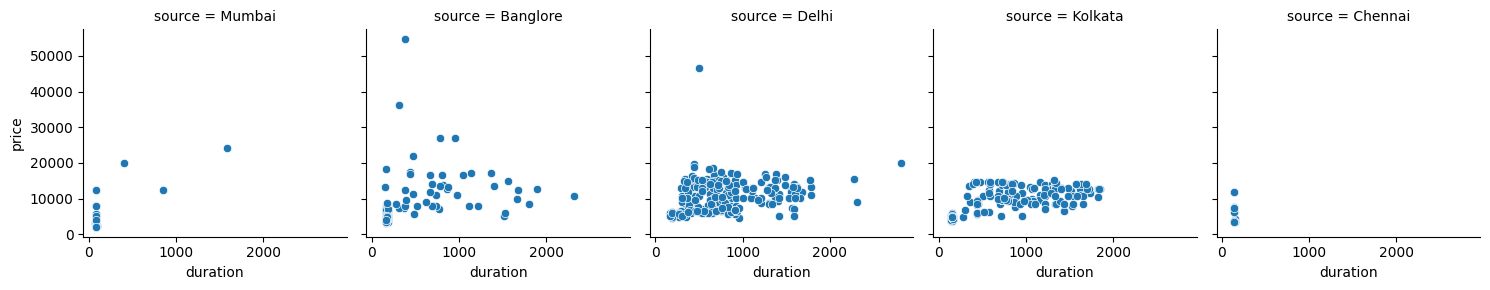

In [93]:
duration_grid = sns.FacetGrid(
    data=train,
    col = "source",
    sharey = True
)

duration_grid.map(sns.scatterplot, "duration", "price")

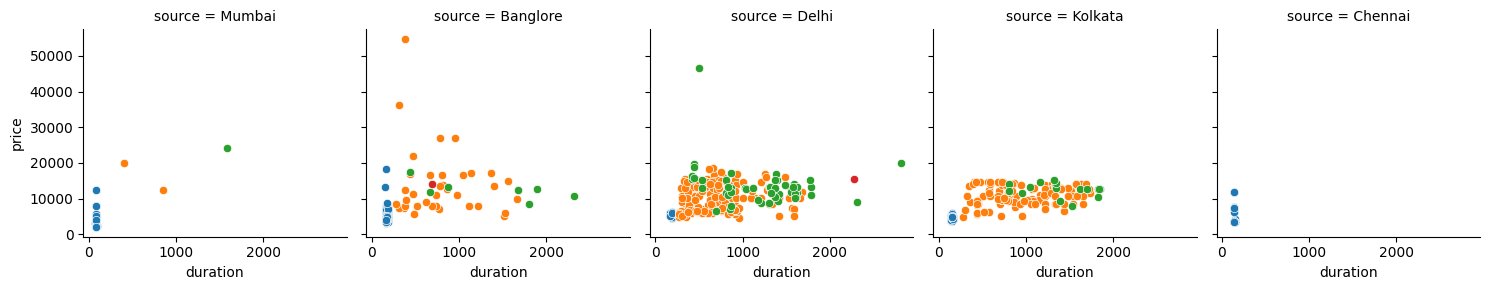

In [94]:
duration_grid = sns.FacetGrid(
    data=train,
    col = "source",
    hue = "total_stops",
    sharey = True
)

duration_grid.map(sns.scatterplot, "duration", "price")

### 9. Automated EDA

In [95]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [96]:
import sys
print(sys.executable)

C:\Users\user\anaconda3\python.exe


In [97]:
%pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [98]:
from ydata_profiling import ProfileReport

In [99]:
report = ProfileReport(train)

In [100]:
report.to_file(output_file="output.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|███████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 70611.18it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]